In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re 
from datetime import datetime

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

sns.set_style("whitegrid")

DATA_PATH = "../data/raw/Car details v3.csv"

df = pd.read_csv(DATA_PATH)

df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [33]:
df.shape

(8128, 13)

In [34]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   str    
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   str    
 5   seller_type    8128 non-null   str    
 6   transmission   8128 non-null   str    
 7   owner          8128 non-null   str    
 8   mileage        7907 non-null   str    
 9   engine         7907 non-null   str    
 10  max_power      7913 non-null   str    
 11  torque         7906 non-null   str    
 12  seats          7907 non-null   float64
dtypes: float64(1), int64(3), str(9)
memory usage: 825.6 KB


In [35]:
df.describe()

,year,selling_price,km_driven,seats
count,8128.000000,8.128000e+03,8.128000e+03,7907.000000
mean,2013.804011,6.382718e+05,6.981951e+04,5.416719
std,4.044249,8.062534e+05,5.655055e+04,0.959588
min,1983.000000,2.999900e+04,1.000000e+00,2.000000
25%,2011.000000,2.549990e+05,3.500000e+04,5.000000
50%,2015.000000,4.500000e+05,6.000000e+04,5.000000
75%,2017.000000,6.750000e+05,9.800000e+04,5.000000
max,2020.000000,1.000000e+07,2.360457e+06,14.000000


In [36]:
print(f"Unique values in each column:\n{df.nunique()}")

Unique values in each column:
name             2058
year               29
selling_price     677
km_driven         921
fuel                4
seller_type         3
transmission        2
owner               5
mileage           393
engine            121
max_power         322
torque            441
seats               9
dtype: int64


In [37]:
for col in ["fuel", "seller_type", "transmission", "owner", "seats"]:
    print(f"\nColumn: {col}")
    print(df[col].unique())


Column: fuel
<StringArray>
['Diesel', 'Petrol', 'LPG', 'CNG']
Length: 4, dtype: str

Column: seller_type
<StringArray>
['Individual', 'Dealer', 'Trustmark Dealer']
Length: 3, dtype: str

Column: transmission
<StringArray>
['Manual', 'Automatic']
Length: 2, dtype: str

Column: owner
<StringArray>
[         'First Owner',         'Second Owner',          'Third Owner',
 'Fourth & Above Owner',       'Test Drive Car']
Length: 5, dtype: str

Column: seats
[ 5.  4. nan  7.  8.  6.  9. 10. 14.  2.]


In [38]:
df.isnull().sum()

name               0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          221
engine           221
max_power        215
torque           222
seats            221
dtype: int64

In [39]:
df_cleaned = df.dropna()

In [40]:
print("Original shape:", df.shape)
print("After dropping missing rows:", df_cleaned.shape)

Original shape: (8128, 13)
After dropping missing rows: (7906, 13)


In [41]:
df_cleaned

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8123,Hyundai i20 Magna,2013,320000,110000,Petrol,Individual,Manual,First Owner,18.5 kmpl,1197 CC,82.85 bhp,113.7Nm@ 4000rpm,5.0
8124,Hyundai Verna CRDi SX,2007,135000,119000,Diesel,Individual,Manual,Fourth & Above Owner,16.8 kmpl,1493 CC,110 bhp,"24@ 1,900-2,750(kgm@ rpm)",5.0
8125,Maruti Swift Dzire ZDi,2009,382000,120000,Diesel,Individual,Manual,First Owner,19.3 kmpl,1248 CC,73.9 bhp,190Nm@ 2000rpm,5.0
8126,Tata Indigo CR4,2013,290000,25000,Diesel,Individual,Manual,First Owner,23.57 kmpl,1396 CC,70 bhp,140Nm@ 1800-3000rpm,5.0


In [42]:
# convert mileage, engine, max_power to numeric by removing units
df_cleaned['mileage'] = df_cleaned['mileage'].str.extract(r'([\d\.]+)')[0].astype(float)
df_cleaned['engine'] = df_cleaned['engine'].str.extract(r'(\d+)')[0].astype(float)
df_cleaned['max_power'] = df_cleaned['max_power'].str.extract(r'([\d\.]+)')[0].astype(float)

# quick check
df_cleaned[['mileage', 'engine', 'max_power']].dtypes

mileage      float64
engine       float64
max_power    float64
dtype: object

In [43]:
def torque_to_nm(s):
    if pd.isna(s):
        return np.nan
    st = str(s).lower()
    st_clean = st.replace(',', '')
    
    #searching torques values with nm unit
    match_nm = re.search(r'([\d\.]+)\s*nm\b', st_clean)
    if match_nm:
        return float(match_nm.group(1))
    
    match_num = re.search(r'([\d\.]+)', st_clean)
    # searching and converting torques values with kgm unit to nm unit
    val = float(match_num.group(1))
    if 'kgm' in st_clean:
        return val * 9.80665
    
    return val

df_cleaned['torque_nm'] = df_cleaned['torque'].apply(torque_to_nm)
df_cleaned[['torque', 'torque_nm']].head(50)

,torque,torque_nm
0,190Nm@ 2000rpm,190.000000
1,250Nm@ 1500-2500rpm,250.000000
2,"12.7@ 2,700(kgm@ rpm)",124.544455
3,22.4 kgm at 1750-2750rpm,219.668960
4,"11.5@ 4,500(kgm@ rpm)",112.776475
5,113.75nm@ 4000rpm,113.750000
6,"7.8@ 4,500(kgm@ rpm)",76.491870
7,59Nm@ 2500rpm,59.000000
8,170Nm@ 1800-2400rpm,170.000000
9,160Nm@ 2000rpm,160.000000


In [44]:
df_cleaned.drop(columns=["torque"], inplace=True)

In [45]:
df_cleaned

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats,torque_nm
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74.00,5.0,190.000000
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0,250.000000
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78.00,5.0,124.544455
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90.00,5.0,219.668960
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.20,5.0,112.776475
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8123,Hyundai i20 Magna,2013,320000,110000,Petrol,Individual,Manual,First Owner,18.50,1197.0,82.85,5.0,113.700000
8124,Hyundai Verna CRDi SX,2007,135000,119000,Diesel,Individual,Manual,Fourth & Above Owner,16.80,1493.0,110.00,5.0,235.359600
8125,Maruti Swift Dzire ZDi,2009,382000,120000,Diesel,Individual,Manual,First Owner,19.30,1248.0,73.90,5.0,190.000000
8126,Tata Indigo CR4,2013,290000,25000,Diesel,Individual,Manual,First Owner,23.57,1396.0,70.00,5.0,140.000000


In [46]:
# converet seats to object type (Numerical -> Categorical)
df_cleaned["seats"] = df_cleaned["seats"].astype("object")

In [47]:
# extract brand from name
df_cleaned["brand"] = df_cleaned["name"].str.split().str[0]

In [48]:
# calculate vehicle age
current_year = datetime.now().year
df_cleaned["vehicle_age"] = current_year - df_cleaned["year"]
df_cleaned[["year", "vehicle_age"]].head()

,year,vehicle_age
0,2014,12
1,2014,12
2,2006,20
3,2010,16
4,2007,19


In [49]:
df_cleaned.drop(columns=["year", "name"], inplace=True)

In [50]:
corr_matrix = df_cleaned.select_dtypes(exclude="object").corr()
corr_matrix

,selling_price,km_driven,mileage,engine,max_power,torque_nm,vehicle_age
selling_price,1.000000,-0.222158,-0.126280,0.455682,0.749674,0.503811,-0.412302
km_driven,-0.222158,1.000000,-0.172980,0.206031,-0.038159,0.082600,0.428548
mileage,-0.126280,-0.172980,1.000000,-0.576408,-0.374621,-0.261574,-0.328544
engine,0.455682,0.206031,-0.576408,1.000000,0.703975,0.625181,-0.018263
max_power,0.749674,-0.038159,-0.374621,0.703975,1.000000,0.698013,-0.226598
torque_nm,0.503811,0.082600,-0.261574,0.625181,0.698013,1.000000,-0.096209
vehicle_age,-0.412302,0.428548,-0.328544,-0.018263,-0.226598,-0.096209,1.000000


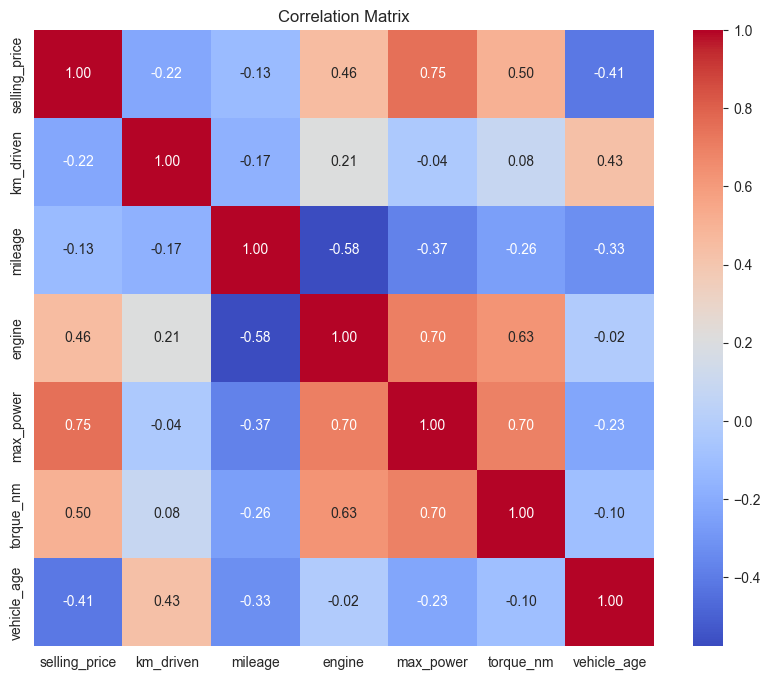

In [51]:
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [52]:
# df_cleaned['brand'].nanunique
df_cleaned['brand'].unique()

array(['Maruti', 'Skoda', 'Honda', 'Hyundai', 'Toyota', 'Ford', 'Renault',
       'Mahindra', 'Tata', 'Chevrolet', 'Datsun', 'Jeep', 'Mercedes-Benz',
       'Mitsubishi', 'Audi', 'Volkswagen', 'BMW', 'Nissan', 'Lexus',
       'Jaguar', 'Land', 'MG', 'Volvo', 'Daewoo', 'Kia', 'Fiat', 'Force',
       'Ambassador', 'Ashok', 'Isuzu', 'Opel'], dtype=object)

Linear Regression Model

In [53]:
X = df_cleaned.drop("selling_price", axis=1)
y = df_cleaned["selling_price"]

In [54]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7906, 12)
y shape: (7906,)


In [55]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [56]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (6324, 12)
X_test: (1582, 12)


In [57]:
numeric_cols = X_train.select_dtypes(exclude="object").columns
categorical_cols = X_train.select_dtypes(include="object").columns

print("Numeric:", numeric_cols)
print("Categorical:", categorical_cols)

Numeric: Index(['km_driven', 'mileage', 'engine', 'max_power', 'torque_nm',
       'vehicle_age'],
      dtype='str')
Categorical: Index(['fuel', 'seller_type', 'transmission', 'owner', 'seats', 'brand'], dtype='str')


C:\Users\Vishnu.K\AppData\Local\Temp\ipykernel_23412\777998780.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_train.select_dtypes(include="object").columns


In [58]:
# Building the preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ]
)

In [59]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

# Building the complete pipeline with a regression model
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

In [60]:
# Training the model
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformer

In [63]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

# Evaluating the model
y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", root_mean_squared_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

MAE: 159233.1324755569
RMSE: 286721.67514546803
R2: 0.8817613630649105
